In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
import numpy as np
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import LambdaCallback
import tensorflow.keras.backend as K

def load_csv(filePath, sep=','):
    return pd.read_csv(filePath, sep=sep)

def split_features_target(df, yColumn, dropColumns):
    X = df.drop(columns=dropColumns + [yColumn])
    y = df[yColumn]
    return X, y

def apply_polynomial(X, degree=2):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    columns = poly.get_feature_names_out(X.columns if isinstance(X, pd.DataFrame) else None)
    return pd.DataFrame(X_poly, columns=columns)

def apply_scaling(X, exclude=[]):
    scaler = MinMaxScaler()

    # Separate excluded columns
    X_excluded = X[exclude]
    
    # Drop excluded columns and scale the rest
    X_dropped = X.drop(columns=exclude)
    X_scaled = scaler.fit_transform(X_dropped)
    
    # Create DataFrame from scaled data
    X_scaled_df = pd.DataFrame(X_scaled, columns=X_dropped.columns, index=X.index)
    
    # Concatenate scaled and excluded columns
    X_combined = pd.concat([X_scaled_df, X_excluded], axis=1)

    # Optional: preserve original column order
    X_combined = X_combined[X.columns]

    return X_combined

def split_data(X, y, test_size=0.4, cv_size=0.5, seed=42):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=test_size, random_state=seed)
    X_cv, X_test, y_cv, y_test = train_test_split(X_temp, y_temp, test_size=cv_size, random_state=seed)
    return X_train, y_train, X_cv, y_cv, X_test, y_test

def apply_encoding(columns, df):
    df = pd.get_dummies(df, columns=columns, drop_first=False)
    return df

def prepare_data(filePath, 
                 yColumn, 
                 csv_sep=',',
                 scale=True,
                 polynomial=False,
                 polyDegree=2,
                 dropColumns=[],
                 exclude_scaling=[],
                 encoding_columns=[]):

    df = load_csv(filePath, sep=csv_sep)

    # Apply feature engineering
    # df = engineer_features(df)

    if(len(encoding_columns)>0):        
        df = apply_encoding(encoding_columns, df)

    # Drop duplicate drops (prevent appending yColumn every call)
    dropCols = list(dropColumns)  # copy list to avoid side effects
    if yColumn not in dropCols:
        dropCols.append(yColumn)

    X, y = split_features_target(df, yColumn, dropCols)

    if polynomial:
        X = apply_polynomial(X, degree=polyDegree)

    if scale:
        X = apply_scaling(X,exclude_scaling)

    return split_data(X, y)


def train_model(X, y, w=None, epochs = 100):
    model = LogisticRegressionCV(max_iter=epochs,
                             solver='lbfgs', 
                             penalty='l2',
                            #  Cs=[0.001, 0.01, 0.1, 1, 10],
                             random_state=52,
                             n_jobs=2, 
                             class_weight='balanced')
    model.fit(X,y, w)

    print('Max Iterations:', epochs)
    print('Training Score: ',model.score(X, y))
    print('Training Cs: ',model.Cs_)
    print('Total Iterations',model.n_iter_)    
    

    return model


def predict_plot(model, X, y, plottingSample = None, predictionLine=True, dotsWithPridction=False):
    y_hats = model.predict(X)

    print('Training Score: ',model.score(X, y))
    print('Training Cs: ',model.Cs_)
    
    if(plottingSample == None):
        plottingSample = len(y_hats)

    plt.scatter(range(plottingSample), y[:plottingSample], label='True Y')
    if dotsWithPridction:
        plt.scatter(range(plottingSample), y_hats[:plottingSample],color='red' )
    if predictionLine:
        plt.plot(range(plottingSample), y_hats[:plottingSample], label='Predicted Y (Line)', color='green')
        
    plt.title('Prediction vs True Values')
    plt.xlabel('Index')
    plt.ylabel('Y Value')
    # plt.legend()
    plt.show()

def combine_datasets(X1, y1, X2, y2):
     X = np.concatenate((X1, X2), axis=0)
     y = np.concatenate((y1, y2), axis=0)
     
     return X,y


In [ ]:
dsPath = '../data/NuralNetwork/multi-class/house_pricing_ multiclass_5_1m_TN_0_FN_0.csv'
yColumn  = 'PriceCategory'
encoding_columns = ['ExteriorQuality','FloorMaterial','SaleSeason']

X_train, y_train, X_cv, y_cv, X_test, y_test = prepare_data(dsPath,
                                                            yColumn,
                                                            dropColumns=[],
                                                            polynomial=True,
                                                            polyDegree=1,
                                                            exclude_scaling=['HasPool', 'HasFireplace'],
                                                            encoding_columns=encoding_columns
                                                             )

# y_train = apply_scaling(pd.DataFrame(y_train,columns=[yColumn]))[yColumn]
# y_test = apply_scaling(pd.DataFrame(y_test,columns=[yColumn]))[yColumn]
# y_cv = apply_scaling(pd.DataFrame(y_cv,columns=[yColumn]))[yColumn]


X = X_train
y = y_train
no_of_features = X.shape[1]

# X, y = combine_datasets(X, y, X_test, y_test)
X, y = combine_datasets(X, y, X_cv, y_cv)

le = LabelEncoder()
y = le.fit_transform(y)
y_test = le.fit_transform(y_test)
# input_dim = int(X_train.shape[1])  # make sure it's an int

# print(X_train.columns)
print(X_train.shape)
print(y_train.shape)

print(X_cv.shape)
print(y_cv.shape)

print(X_test.shape)
print(y_test.shape)
# ExteriorQuality
# ExteriorQuality


(600000, 30)
(600000,)
(200000, 30)
(200000,)
(200000, 30)
(200000,)


In [ ]:

# Set these before using
num_classes = 5
no_of_features = X.shape[1]  # assuming X is your input features
batch_size = 512

model = Sequential([
    Dense(512, activation='relu', input_shape=(no_of_features,)),    
    # Dense(512, activation='relu'),    
    # Dense(512, activation='relu'),    
    # BatchNormalization(),
    Dense(256, activation='relu'),    
    # BatchNormalization(),
    # Dense(128, activation='relu'),    
    # BatchNormalization(),
    # Dense(64, activation='relu'), 
    # Dense(32, activation='relu'), 
    Dense(num_classes, activation='softmax')  # Multiclass output
])

lr_schedule = ExponentialDecay(
    initial_learning_rate=0.05,
    decay_steps=4000,
    decay_rate=0.5,
    staircase=True
)
optimizer = Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',  # use 'categorical_crossentropy' if one-hot encoded
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

lr_logger = LambdaCallback(
    on_epoch_end=lambda epoch, logs: print(
        f" - learning rate = {lr_schedule(optimizer.iterations).numpy():.16f}"
    )
)



history = model.fit(
    X, y,  # y must be integers from 0 to (num_classes - 1)
    epochs=1000000,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[early_stop, lr_logger],
    verbose=1
)


Epoch 1/1000000


Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x0000028200673E20>
Traceback (most recent call last):
  File "C:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\weakref.py", line 370, in remove
    self = selfref()
           ^^^^^^^^^
KeyboardInterrupt: 


In [ ]:
X_test = np.array(X_test)
y_test = np.array(y_test)

# Step 8: Evaluate
print(model.metrics_names)
loss, accuracy = model.evaluate(X,y,batch_size=batch_size)
print(f"\n✅ Test Accuracy: {accuracy}")
print(f"✅ Test Loss: {loss}")

['loss', 'compile_metrics']
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9993 - loss: 0.0060

✅ Test Accuracy: 0.9991524815559387
✅ Test Loss: 0.006212305277585983


131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


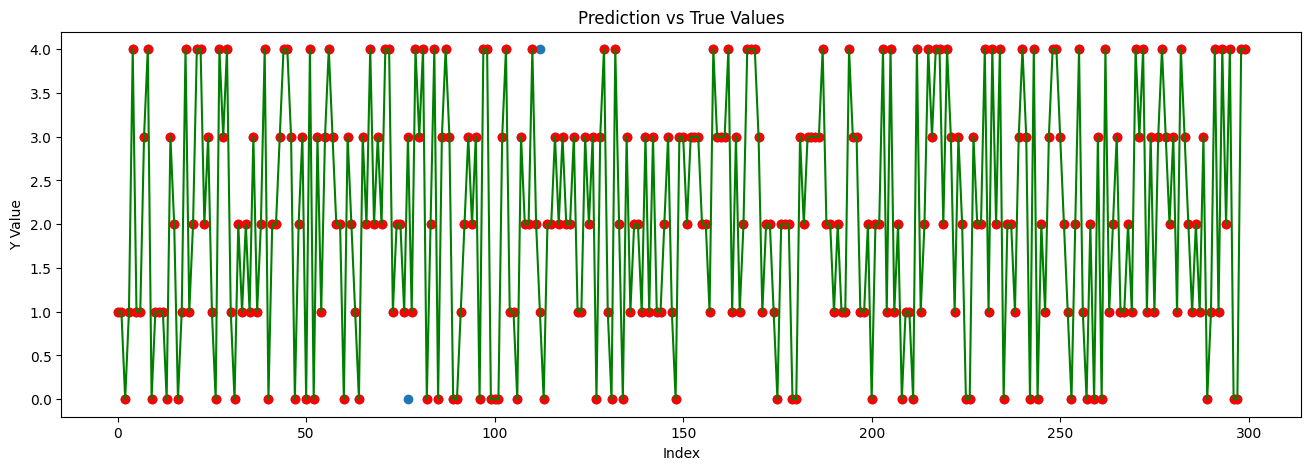

In [ ]:

# Step 9: Predict
y_hats = model.predict(X_test,batch_size=batch_size*3)
y_hats = np.argmax(y_hats, axis=1)
# print(y_hats.shape)


plottingSample = 300
plt.figure(figsize=(16, 5)) 
plt.scatter(range(plottingSample), y_test[:plottingSample], label='True Y')
plt.scatter(range(plottingSample), y_hats[:plottingSample], color='red' )
plt.plot(range(plottingSample), y_hats[:plottingSample], label='Predicted Y (Line)', color='green')
    
plt.title('Prediction vs True Values')
plt.xlabel('Index')
plt.ylabel('Y Value')
# plt.legend()
plt.show()